# ClinVar Benign and Pathogenic Analysis

1. Read the benign and pathogenic text files and remove exact duplicate rows.
2. Find and plot the unique mutation locations and print any overlaps.
3. Automatically identify and compare the most frequently targeted gene.
4. Compare coding and non-coding variations for the top gene.
5. Save one row per unique variation for the top gene and save the overlapping locations.

Rows after removing exact duplicates
Benign:     33,463 (removed 104)
Pathogenic: 6,989 (removed 0)

Unique benign locations: 652
Unique pathogenic locations: 94
Overlapping locations: 1
17:43063909-43063909


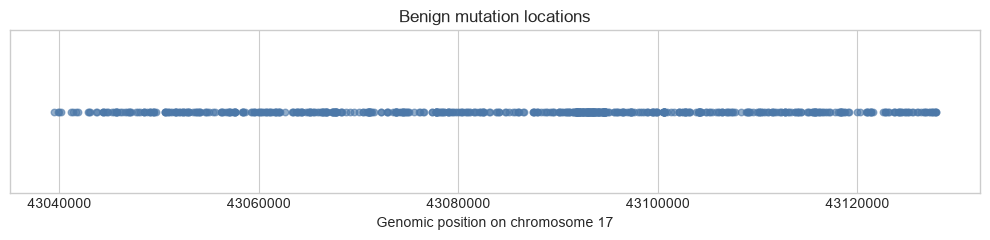

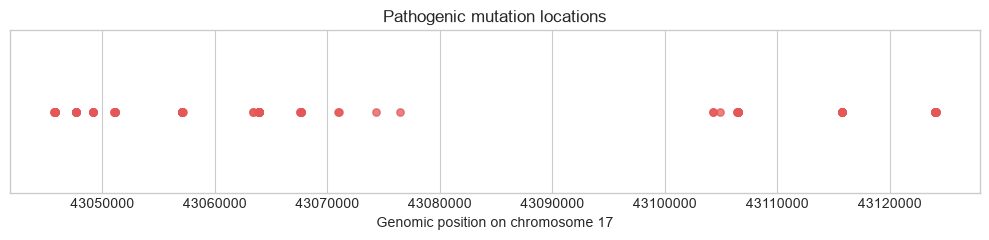


Top gene: BRCA1
Benign        653
Pathogenic     94


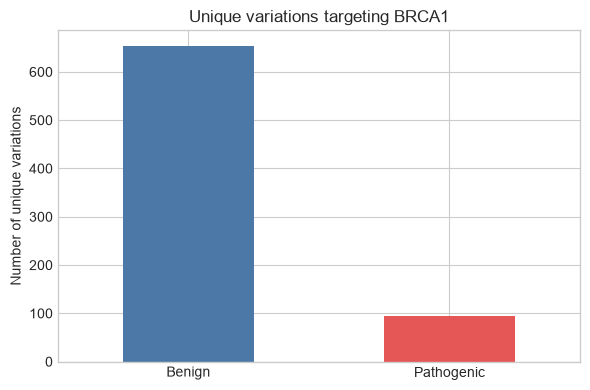

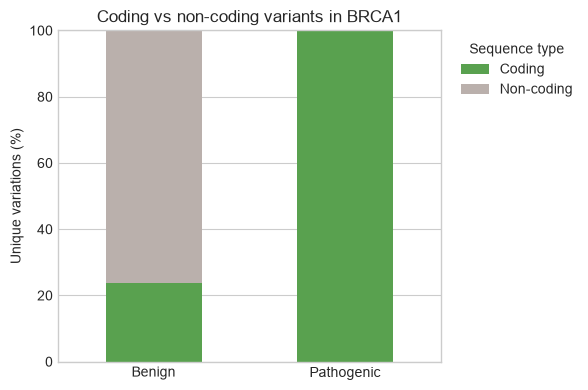


Coding/non-coding percentages
            Benign Pathogenic
Consequence                  
Coding       23.7%     100.0%
Non-coding   76.3%       0.0%

Saved files:
benign_BRCA1_filtered.csv
pathogenic_BRCA1_filtered.csv
overlapping_locations.csv


In [17]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load and clean the data
# ------------------------------------------------------------
data_dir = Path(".")
if not (data_dir / "ClinVar_benign_data.txt").exists():
    data_dir = Path("data")

benign = pd.read_csv(data_dir / "ClinVar_benign_data.txt", sep="\t", low_memory=False)
pathogenic = pd.read_csv(data_dir / "ClinVar_pathogenic_data.txt", sep="\t", low_memory=False)

# Remove only completely identical rows.
benign_clean = benign.drop_duplicates().copy()
pathogenic_clean = pathogenic.drop_duplicates().copy()

def extract_symbol(extra):
    match = re.search(r"(?:^|;)SYMBOL=([^;]+)", str(extra))
    return match.group(1) if match else pd.NA

# The pathogenic file stores the gene symbol inside the Extra column.
pathogenic_clean["_SYMBOL"] = pathogenic_clean["Extra"].map(extract_symbol)

print("Rows after removing exact duplicates")
print(f"Benign:     {len(benign_clean):,} (removed {len(benign) - len(benign_clean):,})")
print(f"Pathogenic: {len(pathogenic_clean):,} (removed {len(pathogenic) - len(pathogenic_clean):,})")

# ------------------------------------------------------------
# 2. Unique locations and overlaps
# ------------------------------------------------------------
benign_unique_locations = benign_clean.drop_duplicates(subset="Location").copy()
pathogenic_unique_locations = pathogenic_clean.drop_duplicates(subset="Location").copy()

benign_locations = set(benign_unique_locations["Location"])
pathogenic_locations = set(pathogenic_unique_locations["Location"])
shared_locations = sorted(benign_locations & pathogenic_locations)

print(f"\nUnique benign locations: {len(benign_locations):,}")
print(f"Unique pathogenic locations: {len(pathogenic_locations):,}")
print(f"Overlapping locations: {len(shared_locations):,}")
for location in shared_locations:
    print(location)

# Save one concise row per overlapping location, not the raw transcript rows.
overlap_records = []
for location in shared_locations:
    benign_match = benign_clean[benign_clean["Location"] == location]
    pathogenic_match = pathogenic_clean[pathogenic_clean["Location"] == location]
    overlap_records.append({
        "Location": location,
        "Benign_variations": ",".join(sorted(benign_match["#Uploaded_variation"].astype(str).unique())),
        "Benign_alleles": ",".join(sorted(benign_match["Allele"].astype(str).unique())),
        "Pathogenic_variations": ",".join(sorted(pathogenic_match["#Uploaded_variation"].astype(str).unique())),
        "Pathogenic_alleles": ",".join(sorted(pathogenic_match["Allele"].astype(str).unique())),
    })
overlap_columns = ["Location", "Benign_variations", "Benign_alleles", "Pathogenic_variations", "Pathogenic_alleles"]
overlap_df = pd.DataFrame(overlap_records, columns=overlap_columns)

# Two separate location plots.
def location_start(location):
    return int(re.search(r":(\d+)", str(location)).group(1))

benign_positions = benign_unique_locations["Location"].map(location_start)
pathogenic_positions = pathogenic_unique_locations["Location"].map(location_start)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.scatter(benign_positions, [0] * len(benign_positions), s=22, alpha=0.6, color="#4C78A8")
ax.set(title="Benign mutation locations", xlabel="Genomic position on chromosome 17")
ax.set_yticks([])
ax.ticklabel_format(style="plain", axis="x")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.scatter(pathogenic_positions, [0] * len(pathogenic_positions), s=28, alpha=0.75, color="#E45756")
ax.set(title="Pathogenic mutation locations", xlabel="Genomic position on chromosome 17")
ax.set_yticks([])
ax.ticklabel_format(style="plain", axis="x")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Automatically find and compare the top gene
# ------------------------------------------------------------
benign_gene_pairs = (
    benign_clean[["#Uploaded_variation", "SYMBOL"]]
    .rename(columns={"SYMBOL": "Gene"})
    .dropna()
    .drop_duplicates()
)
pathogenic_gene_pairs = (
    pathogenic_clean[["#Uploaded_variation", "_SYMBOL"]]
    .rename(columns={"_SYMBOL": "Gene"})
    .dropna()
    .drop_duplicates()
)
all_gene_pairs = pd.concat([benign_gene_pairs, pathogenic_gene_pairs], ignore_index=True)
top_gene = all_gene_pairs["Gene"].value_counts().idxmax()

benign_top_gene = benign_clean[benign_clean["SYMBOL"] == top_gene].copy()
pathogenic_top_gene = pathogenic_clean[pathogenic_clean["_SYMBOL"] == top_gene].copy()

top_gene_counts = pd.Series({
    "Benign": benign_top_gene["#Uploaded_variation"].nunique(),
    "Pathogenic": pathogenic_top_gene["#Uploaded_variation"].nunique(),
})
print(f"\nTop gene: {top_gene}")
print(top_gene_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
top_gene_counts.plot(kind="bar", ax=ax, color=["#4C78A8", "#E45756"])
ax.set(title=f"Unique variations targeting {top_gene}", ylabel="Number of unique variations", xlabel="")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Coding versus non-coding variants for the top gene
# ------------------------------------------------------------
coding_terms = {
    "coding_sequence_variant", "missense_variant", "synonymous_variant",
    "stop_gained", "stop_lost", "start_lost", "frameshift_variant",
    "inframe_insertion", "inframe_deletion", "protein_altering_variant"
}

def has_coding_consequence(consequences):
    terms = set()
    for value in consequences.dropna():
        terms.update(str(value).split(","))
    return bool(terms & coding_terms)

def coding_summary(df):
    coding = df.groupby("#Uploaded_variation")["Consequence"].apply(has_coding_consequence)
    labels = coding.map({True: "Coding", False: "Non-coding"})
    return labels.value_counts().reindex(["Coding", "Non-coding"], fill_value=0)

coding_counts = pd.DataFrame({
    "Benign": coding_summary(benign_top_gene),
    "Pathogenic": coding_summary(pathogenic_top_gene),
})
coding_percent = coding_counts.div(coding_counts.sum(axis=0), axis=1).mul(100)

fig, ax = plt.subplots(figsize=(6, 4))
coding_percent.T.plot(kind="bar", stacked=True, ax=ax, color=["#59A14F", "#BAB0AC"])
ax.set(title=f"Coding vs non-coding variants in {top_gene}", ylabel="Unique variations (%)", xlabel="", ylim=(0, 100))
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Sequence type", frameon=False, bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()
print("\nCoding/non-coding percentages")
print((coding_percent.round(1).astype(str) + "%").to_string())

# ------------------------------------------------------------
# 5. Save three CSV files
# ------------------------------------------------------------
# Keep exactly one row per variation in each exported top-gene file.
benign_top_gene_unique = benign_top_gene.drop_duplicates(subset="#Uploaded_variation").copy()
pathogenic_top_gene_unique = pathogenic_top_gene.drop_duplicates(subset="#Uploaded_variation").copy()

benign_output = data_dir / f"benign_{top_gene}_filtered.csv"
pathogenic_output = data_dir / f"pathogenic_{top_gene}_filtered.csv"
overlap_output = data_dir / "overlapping_locations.csv"

benign_top_gene_unique.to_csv(benign_output, index=False)
pathogenic_top_gene_unique.drop(columns="_SYMBOL").to_csv(pathogenic_output, index=False)
overlap_df.to_csv(overlap_output, index=False)

print("\nSaved files:")
print(f"{benign_output} ({len(benign_top_gene_unique):,} rows)")
print(f"{pathogenic_output} ({len(pathogenic_top_gene_unique):,} rows)")
print(overlap_output)